In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Column names for C-MAPSS FD001
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

# Load data (relative path from notebooks/ folder)
df = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=cols)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:", df.isnull().sum().sum())
print("\nUnique engines:", df['unit'].nunique())

Shape: (20631, 26)

First 5 rows:
   unit  cycle     op1     op2    op3      s1      s2       s3       s4  \
0     1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1     1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2     1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3     1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4     1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  
0  39.06  23.4190  
1  39.00  23.4236  
2  3

In [3]:
# Get the last cycle (failure point) for each engine
max_cycle = df.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']

# Merge back and compute RUL
df = df.merge(max_cycle, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

print("RUL column created.\n")
print(df[['unit', 'cycle', 'RUL']].head(10))
print("\nRUL statistics:")
print(df['RUL'].describe())

RUL column created.

   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187
5     1      6  186
6     1      7  185
7     1      8  184
8     1      9  183
9     1     10  182

RUL statistics:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64


In [4]:
sensor_cols = [f's{i}' for i in range(1, 22)]
constant_sensors = [col for col in sensor_cols if df[col].std() == 0]

print("Constant sensors to drop:", constant_sensors)

df.drop(columns=constant_sensors, inplace=True)

active_sensors = [col for col in df.columns if col.startswith('s')]
print(f"\nActive sensors ({len(active_sensors)}):", active_sensors)
print("\nFinal shape:", df.shape)

Constant sensors to drop: ['s1', 's10', 's18', 's19']

Active sensors (17): ['s2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's20', 's21']

Final shape: (20631, 23)


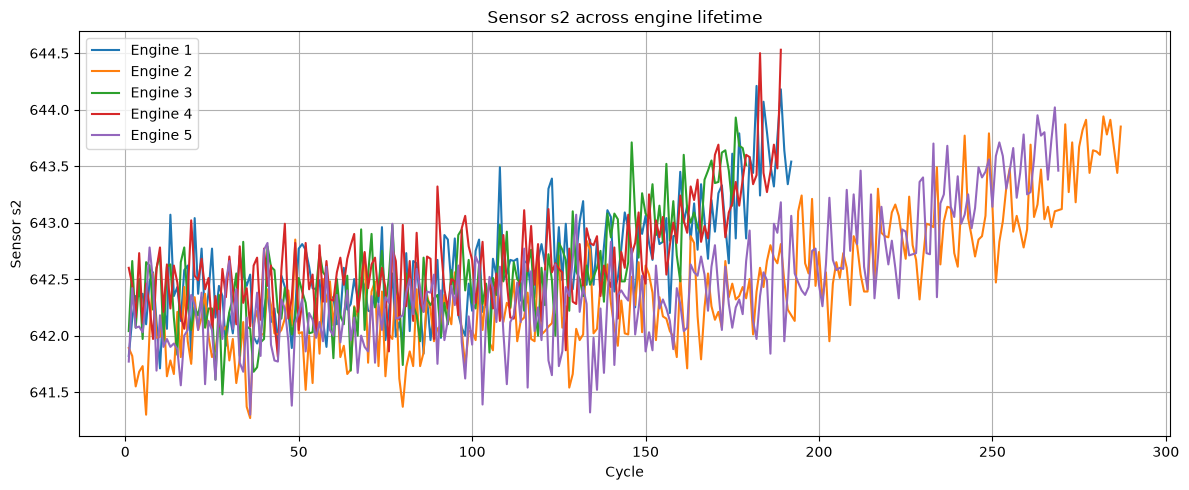

In [5]:
plt.figure(figsize=(12, 5))
for engine_id in [1, 2, 3, 4, 5]:
    engine_data = df[df['unit'] == engine_id]
    plt.plot(engine_data['cycle'], engine_data['s2'], label=f'Engine {engine_id}')

plt.xlabel('Cycle')
plt.ylabel('Sensor s2')
plt.title('Sensor s2 across engine lifetime')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/sensor_exploration.png', dpi=120)
plt.show()